#Herramienta PyCaret

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split, cross_validate, StratifiedKFold
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from xgboost import XGBClassifier


df = pd.read_csv('DatasetEEG_niveles.csv')

features = [c for c in df.columns if 'POW.' in c]
X = df[features]
y = df['nivel_estres']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
print("Distribución del conjunto de entrenamiento:")
print(y_train.value_counts().sort_index())


modelos = {
    'LogReg':  LogisticRegression(max_iter=2000),
    'KNN':     KNeighborsClassifier(),
    'SVM':     SVC(),
    'Tree':    DecisionTreeClassifier(random_state=42),
    'RF':      RandomForestClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'ET':      ExtraTreesClassifier(n_estimators=300, random_state=42, n_jobs=-1),
    'XGB':     XGBClassifier(n_estimators=600, max_depth=8, learning_rate=0.1,
                             subsample=0.8, colsample_bytree=0.8,
                             eval_metric='mlogloss', random_state=42, n_jobs=-1),
}


cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
resultados = {}
for nombre, m in modelos.items():
    print(f"Evaluando {nombre}...")
    pipe = make_pipeline(StandardScaler(), m)
    r = cross_validate(pipe, X_train, y_train, cv=cv,
                       scoring=['accuracy', 'f1_macro'], n_jobs=1)
    resultados[nombre] = {
        'Accuracy':  r['test_accuracy'].mean(),
        'F1 macro':  r['test_f1_macro'].mean(),
        'Desv F1':   r['test_f1_macro'].std(),
    }

tabla = pd.DataFrame(resultados).T.sort_values('F1 macro', ascending=False)
print("\nComparación (validación cruzada en train):")
print(tabla.round(4))


mejor = tabla.index[0]
print(f"\nMejor modelo: {mejor}")
pipe_final = make_pipeline(StandardScaler(), modelos[mejor])
pipe_final.fit(X_train, y_train)
y_pred = pipe_final.predict(X_test)

print("\nResultados de la prueba:")
print(classification_report(y_test, y_pred,
      target_names=['Sin estres', 'Bajo', 'Medio', 'Alto']))

Distribución del conjunto de entrenamiento:
nivel_estres
0    8383
1    2703
2    2702
3    2784
Name: count, dtype: int64
Evaluando LogReg...
Evaluando KNN...
Evaluando SVM...
Evaluando Tree...
Evaluando RF...
Evaluando ET...
Evaluando XGB...

Comparación (validación cruzada en train):
        Accuracy  F1 macro  Desv F1
XGB       0.9339    0.9027   0.0050
LogReg    0.9021    0.8852   0.0021
SVM       0.9103    0.8786   0.0043
RF        0.9095    0.8681   0.0072
ET        0.9085    0.8641   0.0027
KNN       0.8617    0.7958   0.0070
Tree      0.8010    0.7243   0.0117

Mejor modelo: XGB

Resultados de la prueba:
              precision    recall  f1-score   support

  Sin estres       0.99      0.99      0.99      3593
        Bajo       0.91      0.88      0.89      1158
       Medio       0.81      0.84      0.82      1158
        Alto       0.92      0.91      0.92      1194

    accuracy                           0.94      7103
   macro avg       0.91      0.91      0.91      7103

## Modelo XGBoost

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from xgboost import XGBClassifier

df = pd.read_csv('DatasetEEG_niveles.csv')
features = [c for c in df.columns if 'POW.' in c]
X = df[features]
y = df['nivel_estres']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Distribucion del conjunto de entrenamiento:")
print(y_train.value_counts().sort_index())

model = XGBClassifier(
    n_estimators=600,
    max_depth=8,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    eval_metric='mlogloss',
    random_state=42,
    n_jobs=-1
)
print("\nEntrenando XGBoost...")
model.fit(X_train_scaled, y_train)
print("Entrenamiento completo")

y_pred = model.predict(X_test_scaled)

print("\nResultados modelo:")
print(classification_report(y_test, y_pred,
      target_names=['Sin estres', 'Bajo', 'Medio', 'Alto']))

Distribucion del conjunto de entrenamiento:
nivel_estres
0    3850
1    2703
2    2702
3    2784
Name: count, dtype: int64

Entrenando XGBoost...
Entrenamiento completo

Resultados modelo:
              precision    recall  f1-score   support

  Sin estres       0.99      0.99      0.99      1650
        Bajo       0.92      0.88      0.90      1158
       Medio       0.81      0.85      0.83      1158
        Alto       0.92      0.92      0.92      1194

    accuracy                           0.92      5160
   macro avg       0.91      0.91      0.91      5160
weighted avg       0.92      0.92      0.92      5160



###Evolución del modelo

Distribucion del conjunto de entrenamiento:
nivel_estres
0    8383
1    2703
2    2702
3    2784
Name: count, dtype: int64

Entrenando XGBoost...
Entrenamiento completo


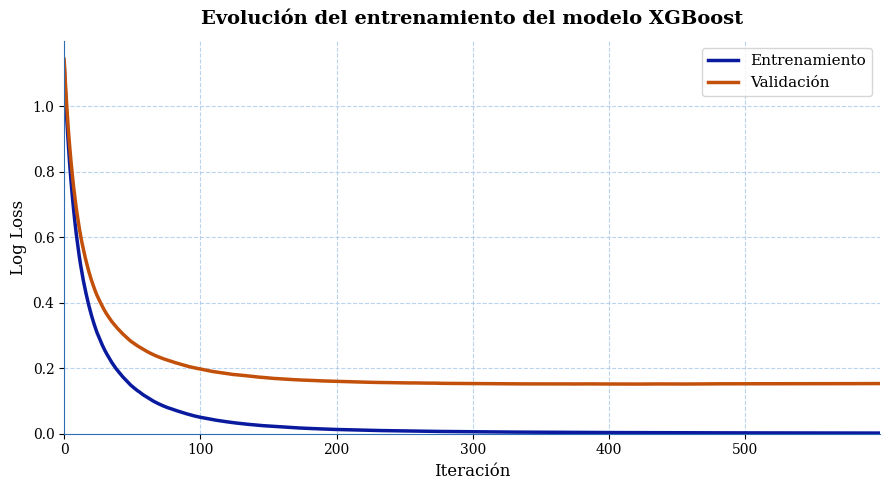

In [5]:
import matplotlib.pyplot as plt
from xgboost import XGBClassifier

df = pd.read_csv('DatasetEEG_niveles.csv')

features = [c for c in df.columns if 'POW.' in c]
X = df[features]
y = df['nivel_estres']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Distribucion del conjunto de entrenamiento:")
print(y_train.value_counts().sort_index())

model = XGBClassifier(n_estimators=600, max_depth=8, learning_rate=0.1, subsample=0.8,
    colsample_bytree=0.8, eval_metric='mlogloss', random_state=42, n_jobs=-1
)

print("\nEntrenando XGBoost...")
model.fit(
    X_train_scaled, y_train,
    eval_set=[(X_train_scaled, y_train), (X_test_scaled, y_test)],
    verbose=False
)
print("Entrenamiento completo")

y_pred = model.predict(X_test_scaled)

resultados = model.evals_result()
loss_train = resultados['validation_0']['mlogloss']
loss_val   = resultados['validation_1']['mlogloss']
iteraciones = range(len(loss_train))

plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(iteraciones, loss_train, color='#0A1A9E', linewidth=2.5, label='Entrenamiento')
ax.plot(iteraciones, loss_val,   color='#C2500A', linewidth=2.5, label='Validación')

ax.set_title('Evolución del entrenamiento del modelo XGBoost',
             fontsize=14, fontweight='bold', pad=12)
ax.set_xlabel('Iteración', fontsize=12)
ax.set_ylabel('Log Loss', fontsize=12)
ax.set_xlim(0, len(loss_train) - 1)
ax.set_ylim(0, max(max(loss_train), max(loss_val)) * 1.05)

ax.grid(True, linestyle='--', color='#A9C8EC', alpha=0.8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#2E6DB4')
ax.spines['bottom'].set_color('#2E6DB4')

ax.legend(loc='upper right', fontsize=11, frameon=True, edgecolor='#CCCCCC')

plt.tight_layout()
plt.show()


## Modelo Regresion logistica

In [2]:
import pandas as pd
import io
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.linear_model import LogisticRegression

df = pd.read_csv('DatasetEEG_niveles.csv')

features = [c for c in df.columns if 'POW.' in c]
X = df[features]
y = df['nivel_estres']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Distribucion del entrenamiento:")
print(y_train.value_counts().sort_index())

logreg_model = LogisticRegression(
    max_iter=2000,
    random_state=42
)

print("\nEntrenando Regresion Logistica...")
logreg_model.fit(X_train_scaled, y_train)
print("Entrenamiento completo")

y_pred_lr = logreg_model.predict(X_test_scaled)

print("\nResultados Regresion Logistica:")
print(classification_report(
    y_test, y_pred_lr,
    target_names=['Sin estres', 'Bajo', 'Medio', 'Alto']
))

Distribucion del entrenamiento:
nivel_estres
0    8383
1    2703
2    2702
3    2784
Name: count, dtype: int64

Entrenando Regresion Logistica...
Entrenamiento completo

Resultados Regresion Logistica:
              precision    recall  f1-score   support

  Sin estres       0.91      0.94      0.93      3593
        Bajo       0.88      0.81      0.85      1158
       Medio       0.84      0.83      0.83      1158
        Alto       0.90      0.90      0.90      1194

    accuracy                           0.89      7103
   macro avg       0.88      0.87      0.88      7103
weighted avg       0.89      0.89      0.89      7103



##Modelo SVM

In [3]:
import pandas as pd
import io
from google.colab import files
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report
from sklearn.svm import SVC

df = pd.read_csv('DatasetEEG_niveles.csv')

features = [c for c in df.columns if 'POW.' in c]
X = df[features]
y = df['nivel_estres']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print("Distribucion del entrenamiento:")
print(y_train.value_counts().sort_index())

svm_model = SVC(
    kernel='rbf',
    C=1.0,
    gamma='scale',
    random_state=42
)

print("\nEntrenando SVM...")
svm_model.fit(X_train_scaled, y_train)
print("Entrenamiento completo")

y_pred_svm = svm_model.predict(X_test_scaled)

print("\nResultados SVM:")
print(classification_report(
    y_test, y_pred_svm,
    target_names=['Sin estres', 'Bajo', 'Medio', 'Alto']
))

Distribucion del entrenamiento:
nivel_estres
0    8383
1    2703
2    2702
3    2784
Name: count, dtype: int64

Entrenando SVM...
Entrenamiento completo

Resultados SVM:
              precision    recall  f1-score   support

  Sin estres       0.95      0.99      0.97      3593
        Bajo       0.92      0.82      0.87      1158
       Medio       0.79      0.82      0.80      1158
        Alto       0.92      0.88      0.90      1194

    accuracy                           0.91      7103
   macro avg       0.89      0.88      0.88      7103
weighted avg       0.91      0.91      0.91      7103



##Evolución del modelo